# Regressione Random Forest

Proseguendo il percorso di questo progetto, l'obiettivo di questo notebook è allenare un modello capace di compiere previsioni della qualità dell'aria su base oraria e giornaliera. Tuttavia, al contrario di quanto avvenuto per la classificazione, vogliamo estrarre predizioni quantitative e non qualitative. Per farlo usiamo un algoritmo del tipo Random Forest Regressor.

Questo algoritmo crea una foresta di alberi decisionali le cui foglie non corrispondono più a classi ma a valori numerici, pertanto, la predizione non corrisponde più alla classe predetta dalla maggioranza degli alberi ma alla media delle predizioni numeriche di tutti gli alberi.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.regr_funcs as fs

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 12

# Modelli orari

Come negli altri notebook, cominciamo cercando di compiere predizioni per l'ora successiva. Questo chiaramente ha un'utilità pratica minore nella maggior parte dei casi ma ci permette di lavorare con molti più dati e, pertanto, ci aspettiamo predizioni più accurate e precise.

## PM10

In [3]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
hour_PM10_df = pd.read_csv('../../data/processed/dataset_hour_PM10_processed.csv')
hour_PM10_df.dropna(inplace=True)

### Pipeline

In [4]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_PM10_df.columns if col.startswith('station_')]
num_features = hour_PM10_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_PM10_h = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_PM10_h = Pipeline([('preprocessor', preprocessor_PM10_h), ('regressor', RandomForestRegressor(random_state=seed))])

# griglia degli iperparametri
#param_grid_rfr = {'regressor__n_estimators': [100, 200, 500],                   # numero di alberi
#                    'regressor__max_depth': [5, 10, 20, None],                  # massima profondità degli alberi
#                    'regressor__min_samples_split': [2, 5, 10],                 # numero minimo di sample per creare una diramazione
#                    'regressor__min_samples_leaf': [1, 2, 5],                   # numero minimo di sample per foglia
#                    'regressor__max_features': [1.0, 'sqrt', 'log2'],           # numero massimo di feature considerate per uno split
#                    'regressor__bootstrap': [True, False]}                      # bootstrap


param_grid_rfr = {'regressor__n_estimators': [200],                              # numero di alberi
                    'regressor__max_depth': [5],                                 # massima profondità degli alberi
                    'regressor__min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'regressor__min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'regressor__max_features': [1.0, 'sqrt'],                    # numero massimo di feature considerate per uno split
                    'regressor__bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_PM10_h = GridSearchCV(estimator=pipeline_PM10_h,                                 # usiamo Random Forest con la pipeline integrata
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [5]:
# splittiamo il dataset
feature_cols = list(num_features) + list(non_num_features)

# creiamo train e test
PM10_h_X_train, PM10_h_X_test, PM10_h_y_train, PM10_h_y_test = fs.get_train_test(hour_PM10_df, 0.8, feature_cols)

### Allenamento modello

In [6]:
# training
rfr_PM10_h.fit(PM10_h_X_train, PM10_h_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['NO2_1', 'PM10_1', 'PM10_2', 'PM10_3', 'PM10_diff_1', 'PM10_diff_2',
       'cos_hour', 'cos_week_day', 'day', 'elevation', 'power_area_50_1',
       'power_area_50_2', 'precipitation', '...
                                                                          'station_Rovereto',
                                                                          'station_Via '
                                                                          'Bolzano'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=12))]),
             n_jobs=-1,
             param_grid={'regressor__bootstrap': [True],
                         'regressor__max_depth': [5],
                         'regressor__max_features': [1.0, 'sqrt'],
                         'regressor__min_samples_leaf': [5],
                         'regressor__min_samples_split': [2],
                         'regressor__n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [7]:
print("Best score:")
print(rfr_PM10_h.best_score_)
# miglior modello
best_rfr_PM10_h = rfr_PM10_h.best_estimator_

Best score:
-6.321136752922345


### Studio importanza features

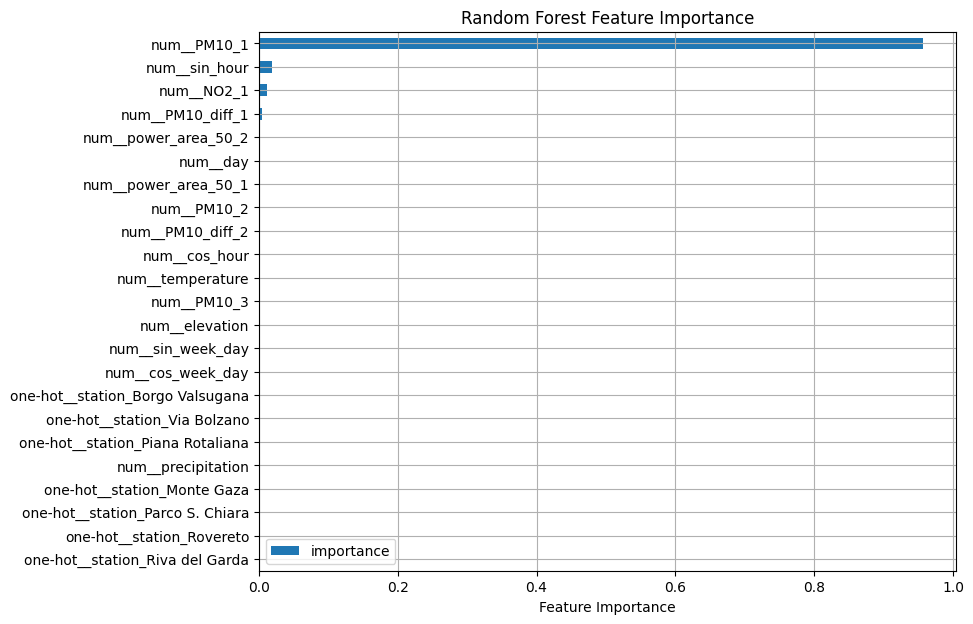

In [8]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfr_PM10_h.named_steps['preprocessor'].get_feature_names_out())

PM10_h_model = best_rfr_PM10_h.named_steps['regressor']

fs.display_importances(PM10_h_model, feature_names)

### Valutazione performance

In [9]:
full_PM10_h_tr = PM10_h_X_train.copy()
full_PM10_h_tr['actual'] = PM10_h_y_train
full_PM10_h_tr['prediction'] = best_rfr_PM10_h.predict(PM10_h_X_train)

full_PM10_h_te = PM10_h_X_test.copy()
full_PM10_h_te['actual'] = PM10_h_y_test
full_PM10_h_te['prediction'] = best_rfr_PM10_h.predict(PM10_h_X_test)

print('Performance su train')
fs.evaluation(full_PM10_h_tr['actual'], full_PM10_h_tr['prediction'])
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(full_PM10_h_te['actual'], full_PM10_h_te['prediction'])

Performance su train
Mean Squared Error (MSE):          33.530120848832986
Root Mean Squared Error (RMSE):    5.7905199117896995
Mean Absolute Error (MAE):         3.0725385476606606
Coefficient of Determination (R2): 0.9060888829389466
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          33.40374712495616
Root Mean Squared Error (RMSE):    5.77959748814363
Mean Absolute Error (MAE):         3.7004860093009873
Coefficient of Determination (R2): 0.9393085975899631


(33.40374712495616, 5.77959748814363, 3.7004860093009873, 0.9393085975899631)

### Grafici previsioni

In [10]:
# aggiungiamo il tempo
full_PM10_h_tr = fs.add_time(full_PM10_h_tr)
full_PM10_h_te = fs.add_time(full_PM10_h_te)

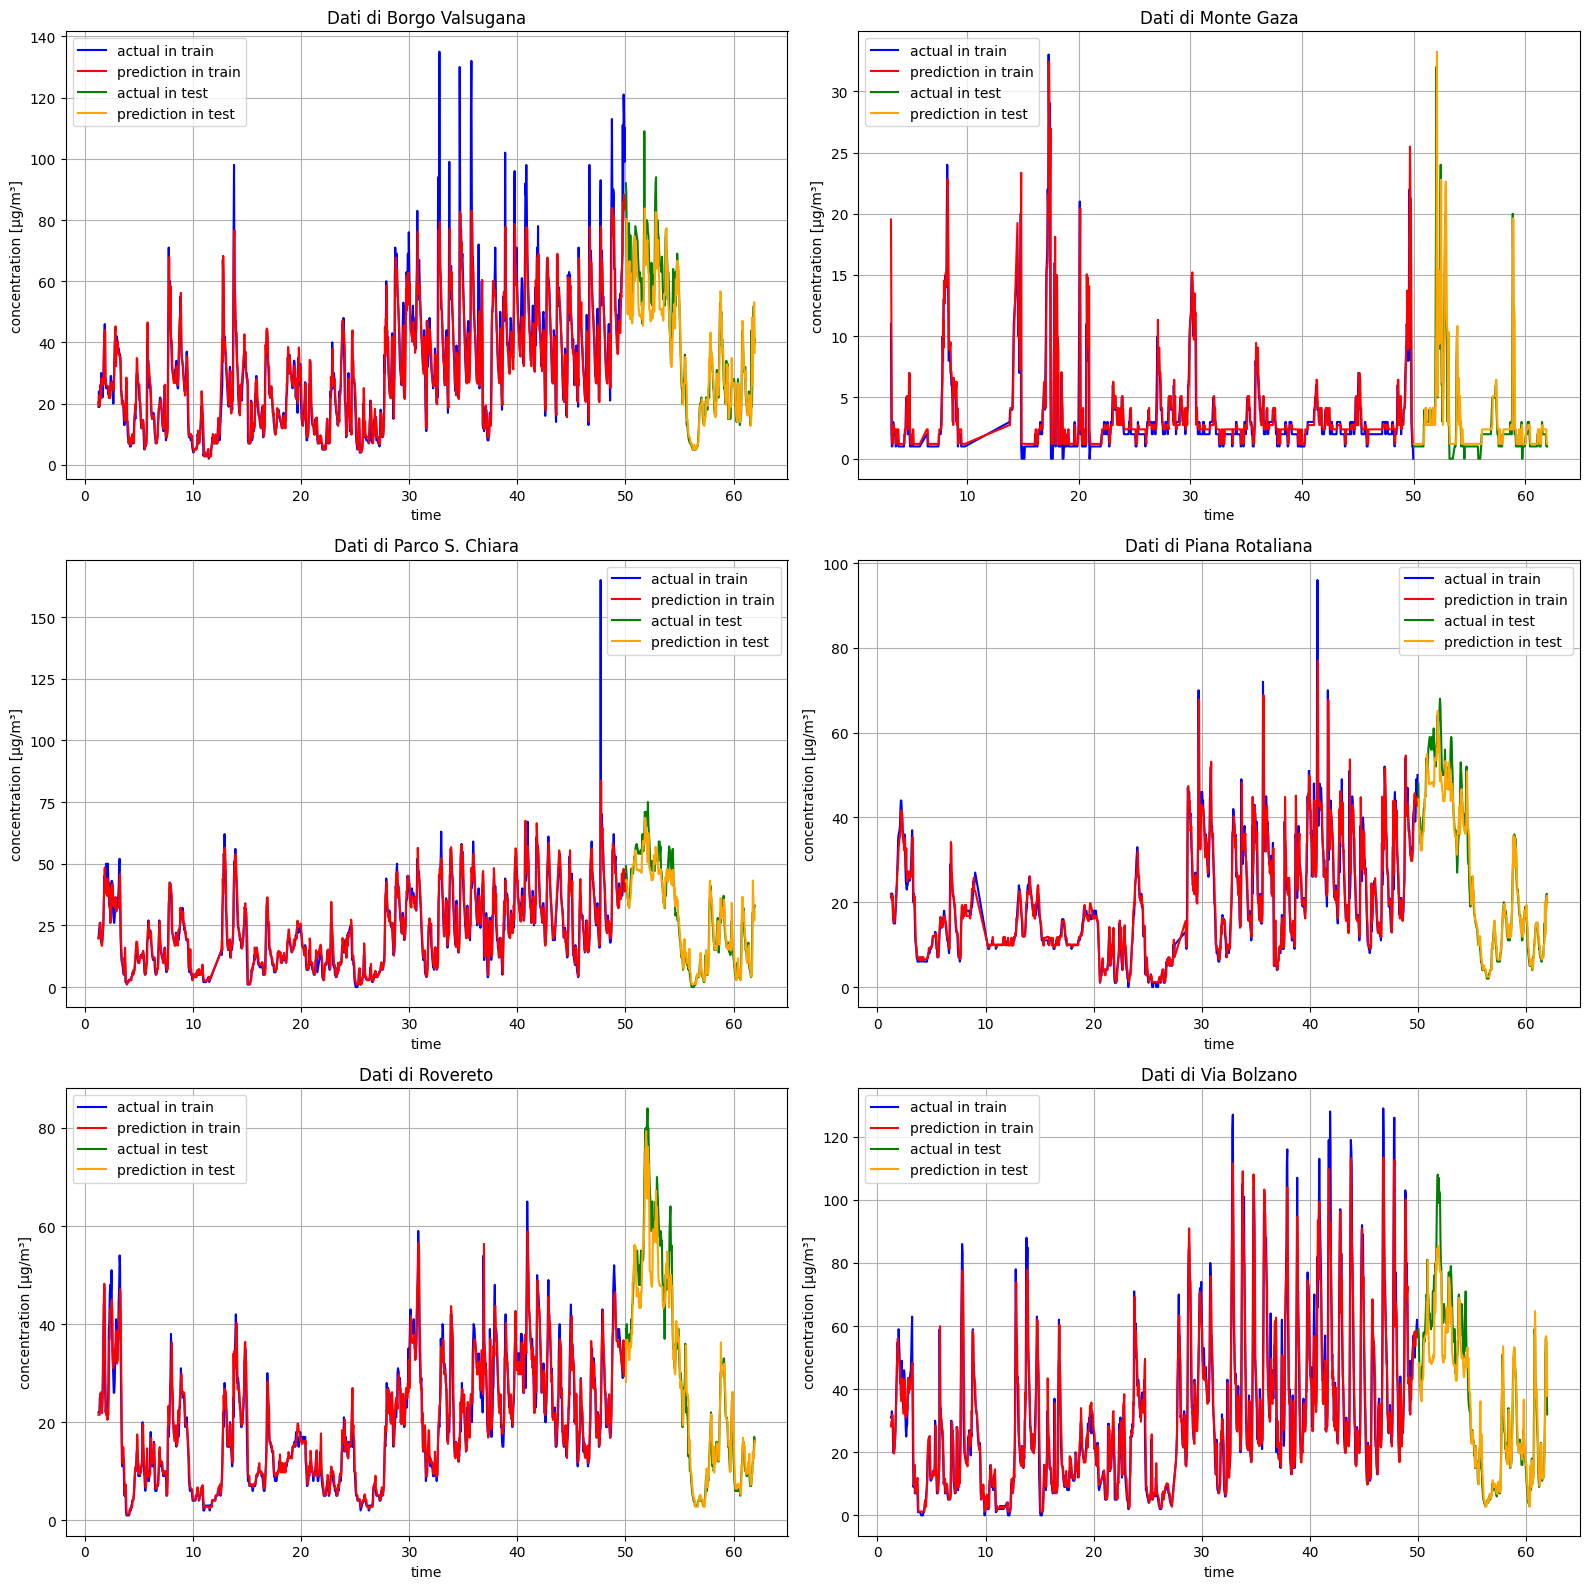

In [11]:
fs.plot_predictions(full_PM10_h_tr, full_PM10_h_te)

## PM2.5

In [12]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
hour_PM25_df = pd.read_csv('../../data/processed/dataset_hour_PM2_5_processed.csv')
hour_PM25_df.dropna(inplace=True)

### Pipeline

In [13]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_PM25_df.columns if col.startswith('station_')]
num_features = hour_PM25_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_PM25_h = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_PM25_h = Pipeline([('preprocessor', preprocessor_PM25_h), ('regressor', RandomForestRegressor(random_state=seed))])

# griglia degli iperparametri
#param_grid_rfr = {'regressor__n_estimators': [100, 200, 500],                   # numero di alberi
#                    'regressor__max_depth': [5, 10, 20, None],                  # massima profondità degli alberi
#                    'regressor__min_samples_split': [2, 5, 10],                 # numero minimo di sample per creare una diramazione
#                    'regressor__min_samples_leaf': [1, 2, 5],                   # numero minimo di sample per foglia
#                    'regressor__max_features': [1.0, 'sqrt', 'log2'],           # numero massimo di feature considerate per uno split
#                    'regressor__bootstrap': [True, False]}                      # bootstrap


param_grid_rfr = {'regressor__n_estimators': [200],                              # numero di alberi
                    'regressor__max_depth': [5],                                 # massima profondità degli alberi
                    'regressor__min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'regressor__min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'regressor__max_features': [1.0, 'sqrt'],                    # numero massimo di feature considerate per uno split
                    'regressor__bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_PM25_h = GridSearchCV(estimator=pipeline_PM25_h,                                 # usiamo Random Forest con la pipeline integrata
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

In [14]:
# splittiamo il dataset
feature_cols = list(num_features) + list(non_num_features)

# creiamo train e test
PM25_h_X_train, PM25_h_X_test, PM25_h_y_train, PM25_h_y_test = fs.get_train_test(hour_PM25_df, 0.8, feature_cols)

### Allenamento modello

In [15]:
# training
rfr_PM25_h.fit(PM25_h_X_train, PM25_h_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['NO2_1', 'PM2.5_1', 'PM2.5_2', 'PM2.5_3', 'PM2.5_diff_1',
       'PM2.5_diff_2', 'cos_hour', 'cos_week_day', 'day', 'elevation',
       'power_area_50_1', 'power_area_50_2', 'precipitati...
                                                                          'station_Rovereto',
                                                                          'station_Via '
                                                                          'Bolzano'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=12))]),
             n_jobs=-1,
             param_grid={'regressor__bootstrap': [True],
                         'regressor__max_depth': [5],
                         'regressor__max_features': [1.0, 'sqrt'],
                         'regressor__min_samples_leaf': [5],
                         'regressor__min_samples_split': [2],
                         'regressor__n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [16]:
print("Best score:")
print(rfr_PM25_h.best_score_)
# miglior modello
best_rfr_PM25_h = rfr_PM25_h.best_estimator_

Best score:
-5.095233813251338


### Studio importanza features

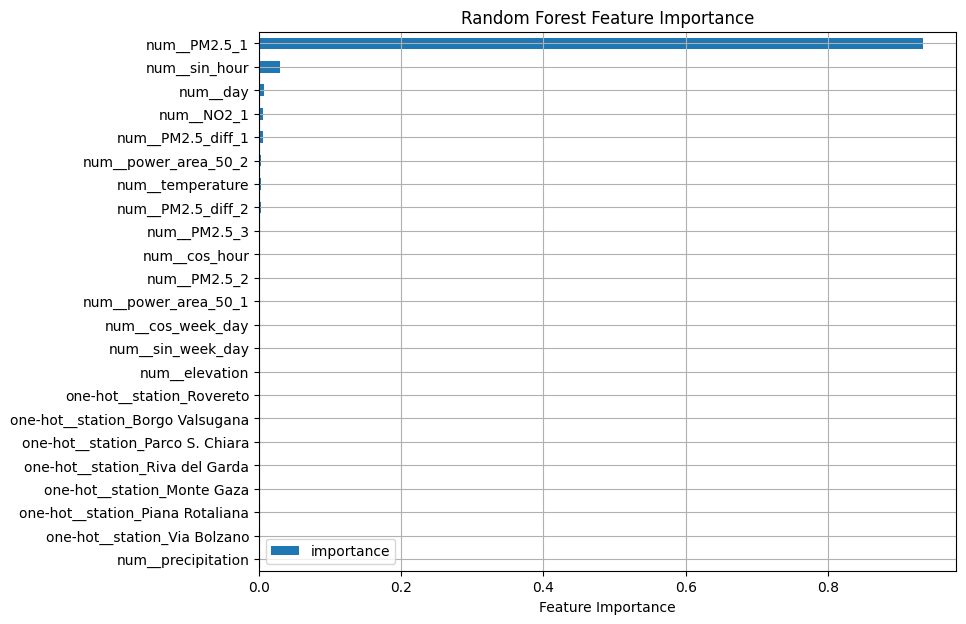

In [17]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfr_PM25_h.named_steps['preprocessor'].get_feature_names_out())

PM25_h_model = best_rfr_PM25_h.named_steps['regressor']

fs.display_importances(PM25_h_model, feature_names)

### Valutazione performance

In [18]:
full_PM25_h_tr = PM25_h_X_train.copy()
full_PM25_h_tr['actual'] = PM25_h_y_train
full_PM25_h_tr['prediction'] = best_rfr_PM25_h.predict(PM25_h_X_train)

full_PM25_h_te = PM25_h_X_test.copy()
full_PM25_h_te['actual'] = PM25_h_y_test
full_PM25_h_te['prediction'] = best_rfr_PM25_h.predict(PM25_h_X_test)

print('Performance su train')
fs.evaluation(full_PM25_h_tr['actual'], full_PM25_h_tr['prediction'])
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(full_PM25_h_te['actual'], full_PM25_h_te['prediction'])

Performance su train
Mean Squared Error (MSE):          18.602815092314632
Root Mean Squared Error (RMSE):    4.31309808517203
Mean Absolute Error (MAE):         2.5433243277237256
Coefficient of Determination (R2): 0.8762696274999124
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          25.420936014300043
Root Mean Squared Error (RMSE):    5.04191789047581
Mean Absolute Error (MAE):         3.6044000729208743
Coefficient of Determination (R2): 0.9162181028275536


(25.420936014300043, 5.04191789047581, 3.6044000729208743, 0.9162181028275536)

### Grafici previsioni

In [19]:
# aggiungiamo il tempo
full_PM25_h_tr = fs.add_time(full_PM25_h_tr)
full_PM25_h_te = fs.add_time(full_PM25_h_te)

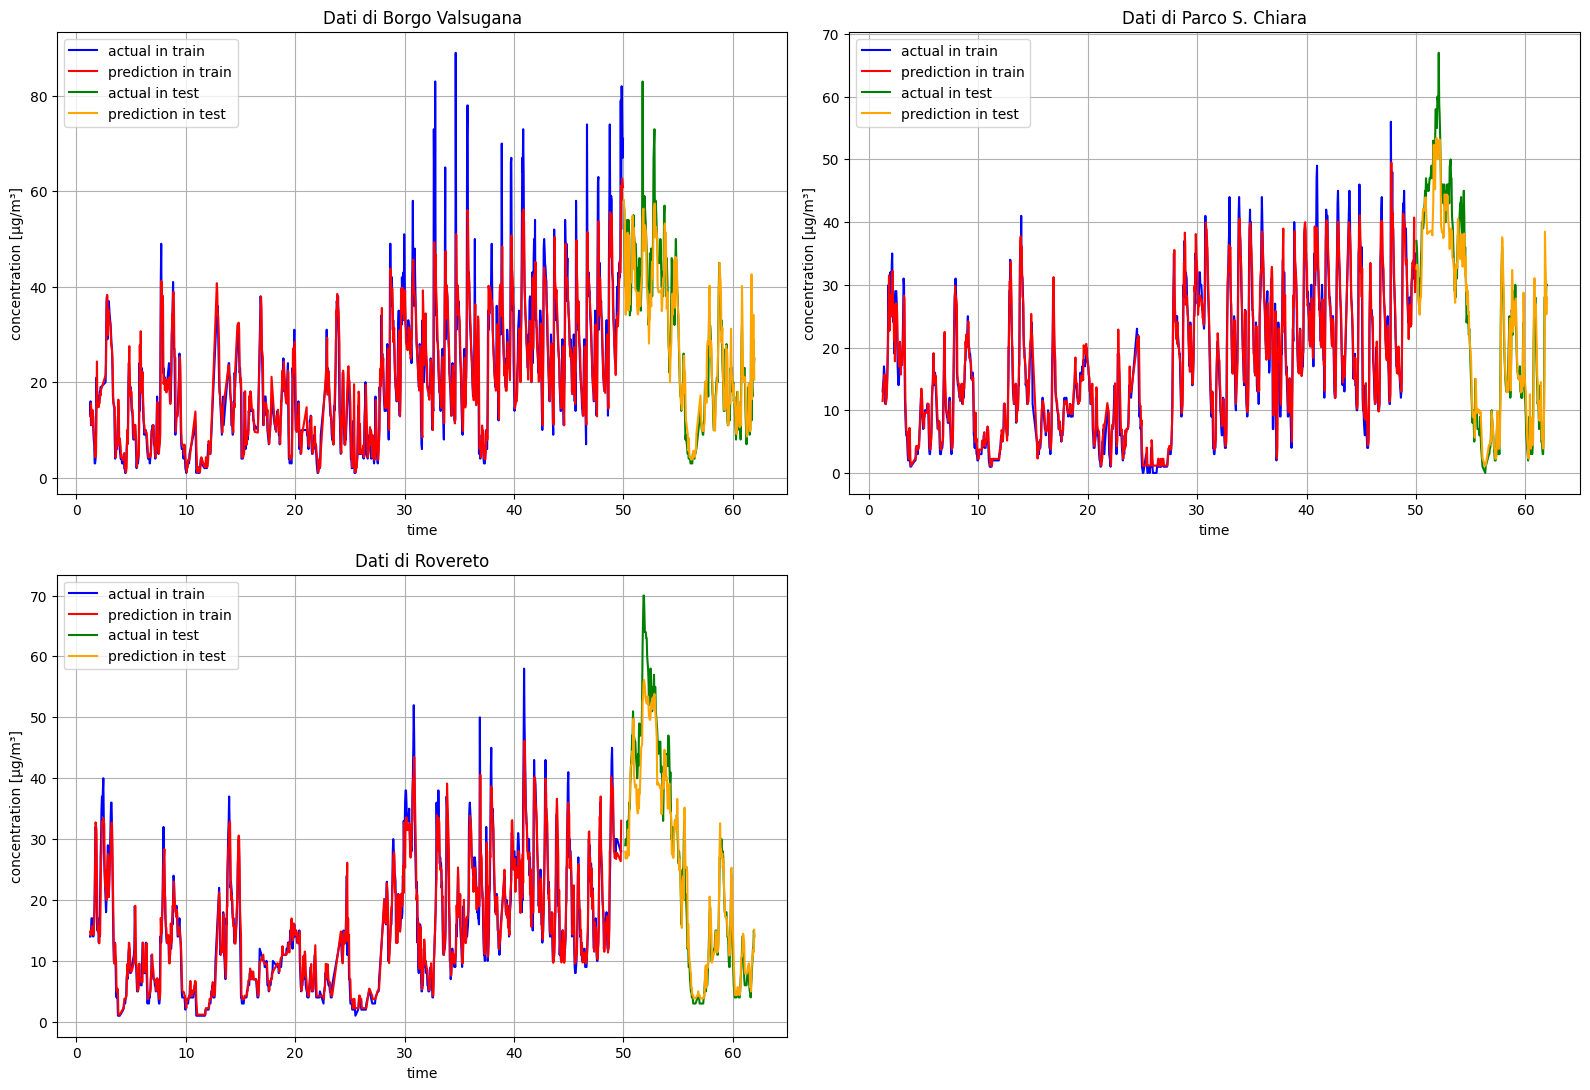

In [20]:
fs.plot_predictions(full_PM25_h_tr, full_PM25_h_te)

## Ozono

In [21]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
hour_O3_df = pd.read_csv('../../data/processed/dataset_hour_O3_processed.csv')
hour_O3_df.dropna(inplace=True)

### Pipeline

In [22]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_O3_df.columns if col.startswith('station_')]
num_features = hour_O3_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_O3_h = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_O3_h = Pipeline([('preprocessor', preprocessor_O3_h), ('regressor', RandomForestRegressor(random_state=seed))])

# griglia degli iperparametri
#param_grid_rfr = {'regressor__n_estimators': [100, 200, 500],                   # numero di alberi
#                    'regressor__max_depth': [5, 10, 20, None],                  # massima profondità degli alberi
#                    'regressor__min_samples_split': [2, 5, 10],                 # numero minimo di sample per creare una diramazione
#                    'regressor__min_samples_leaf': [1, 2, 5],                   # numero minimo di sample per foglia
#                    'regressor__max_features': [1.0, 'sqrt', 'log2'],           # numero massimo di feature considerate per uno split
#                    'regressor__bootstrap': [True, False]}                      # bootstrap


param_grid_rfr = {'regressor__n_estimators': [200],                              # numero di alberi
                    'regressor__max_depth': [5],                                 # massima profondità degli alberi
                    'regressor__min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'regressor__min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'regressor__max_features': [1.0, 'sqrt'],                    # numero massimo di feature considerate per uno split
                    'regressor__bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_O3_h = GridSearchCV(estimator=pipeline_O3_h,                                 # usiamo Random Forest con la pipeline integrata
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

In [23]:
# splittiamo il dataset
feature_cols = list(num_features) + list(non_num_features)

# creiamo train e test
O3_h_X_train, O3_h_X_test, O3_h_y_train, O3_h_y_test = fs.get_train_test(hour_O3_df, 0.8, feature_cols)

### Allenamento modello

In [24]:
# training
rfr_O3_h.fit(O3_h_X_train, O3_h_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['NO2_1', 'O3_1', 'O3_2', 'O3_3', 'O3_diff_1', 'O3_diff_2', 'PM10_1',
       'cos_hour', 'cos_week_day', 'day', 'elevation', 'power_area_50_1',
       'power_area_50_2', 'precipitation', 's...
                                                                          'station_Rovereto',
                                                                          'station_Via '
                                                                          'Bolzano'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=12))]),
             n_jobs=-1,
             param_grid={'regressor__bootstrap': [True],
                         'regressor__max_depth': [5],
                         'regressor__max_features': [1.0, 'sqrt'],
                         'regressor__min_samples_leaf': [5],
                         'regressor__min_samples_split': [2],
                         'regressor__n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [25]:
print("Best score:")
print(rfr_O3_h.best_score_)
# miglior modello
best_rfr_O3_h = rfr_O3_h.best_estimator_

Best score:
-5.864075583078394


### Studio importanza features

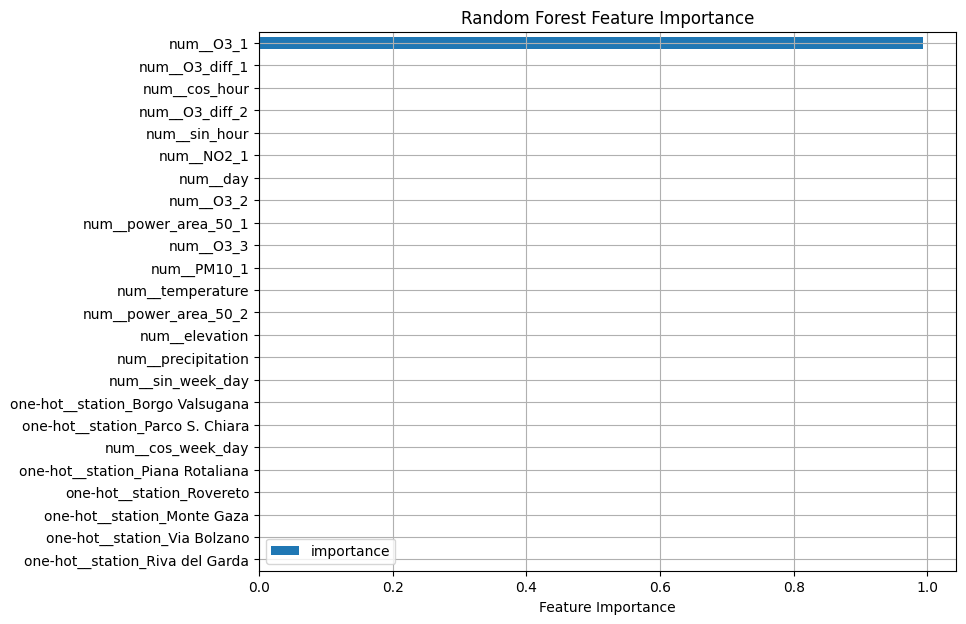

In [26]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfr_O3_h.named_steps['preprocessor'].get_feature_names_out())

O3_h_model = best_rfr_O3_h.named_steps['regressor']

fs.display_importances(O3_h_model, feature_names)

### Valutazione performance

In [27]:
full_O3_h_tr = O3_h_X_train.copy()
full_O3_h_tr['actual'] = O3_h_y_train
full_O3_h_tr['prediction'] = best_rfr_O3_h.predict(O3_h_X_train)

full_O3_h_te = O3_h_X_test.copy()
full_O3_h_te['actual'] = O3_h_y_test
full_O3_h_te['prediction'] = best_rfr_O3_h.predict(O3_h_X_test)

print('Performance su train')
fs.evaluation(full_O3_h_tr['actual'], full_O3_h_tr['prediction'])
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(full_O3_h_te['actual'], full_O3_h_te['prediction'])

Performance su train
Mean Squared Error (MSE):          20.940942671689793
Root Mean Squared Error (RMSE):    4.576127475463265
Mean Absolute Error (MAE):         2.7302621884595033
Coefficient of Determination (R2): 0.9750524321799218
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          14.82846767898743
Root Mean Squared Error (RMSE):    3.850774945252894
Mean Absolute Error (MAE):         2.2456706016077175
Coefficient of Determination (R2): 0.9828709222917602


(14.82846767898743, 3.850774945252894, 2.2456706016077175, 0.9828709222917602)

### Grafici previsioni

In [28]:
# aggiungiamo il tempo
full_O3_h_tr = fs.add_time(full_O3_h_tr)
full_O3_h_te = fs.add_time(full_O3_h_te)

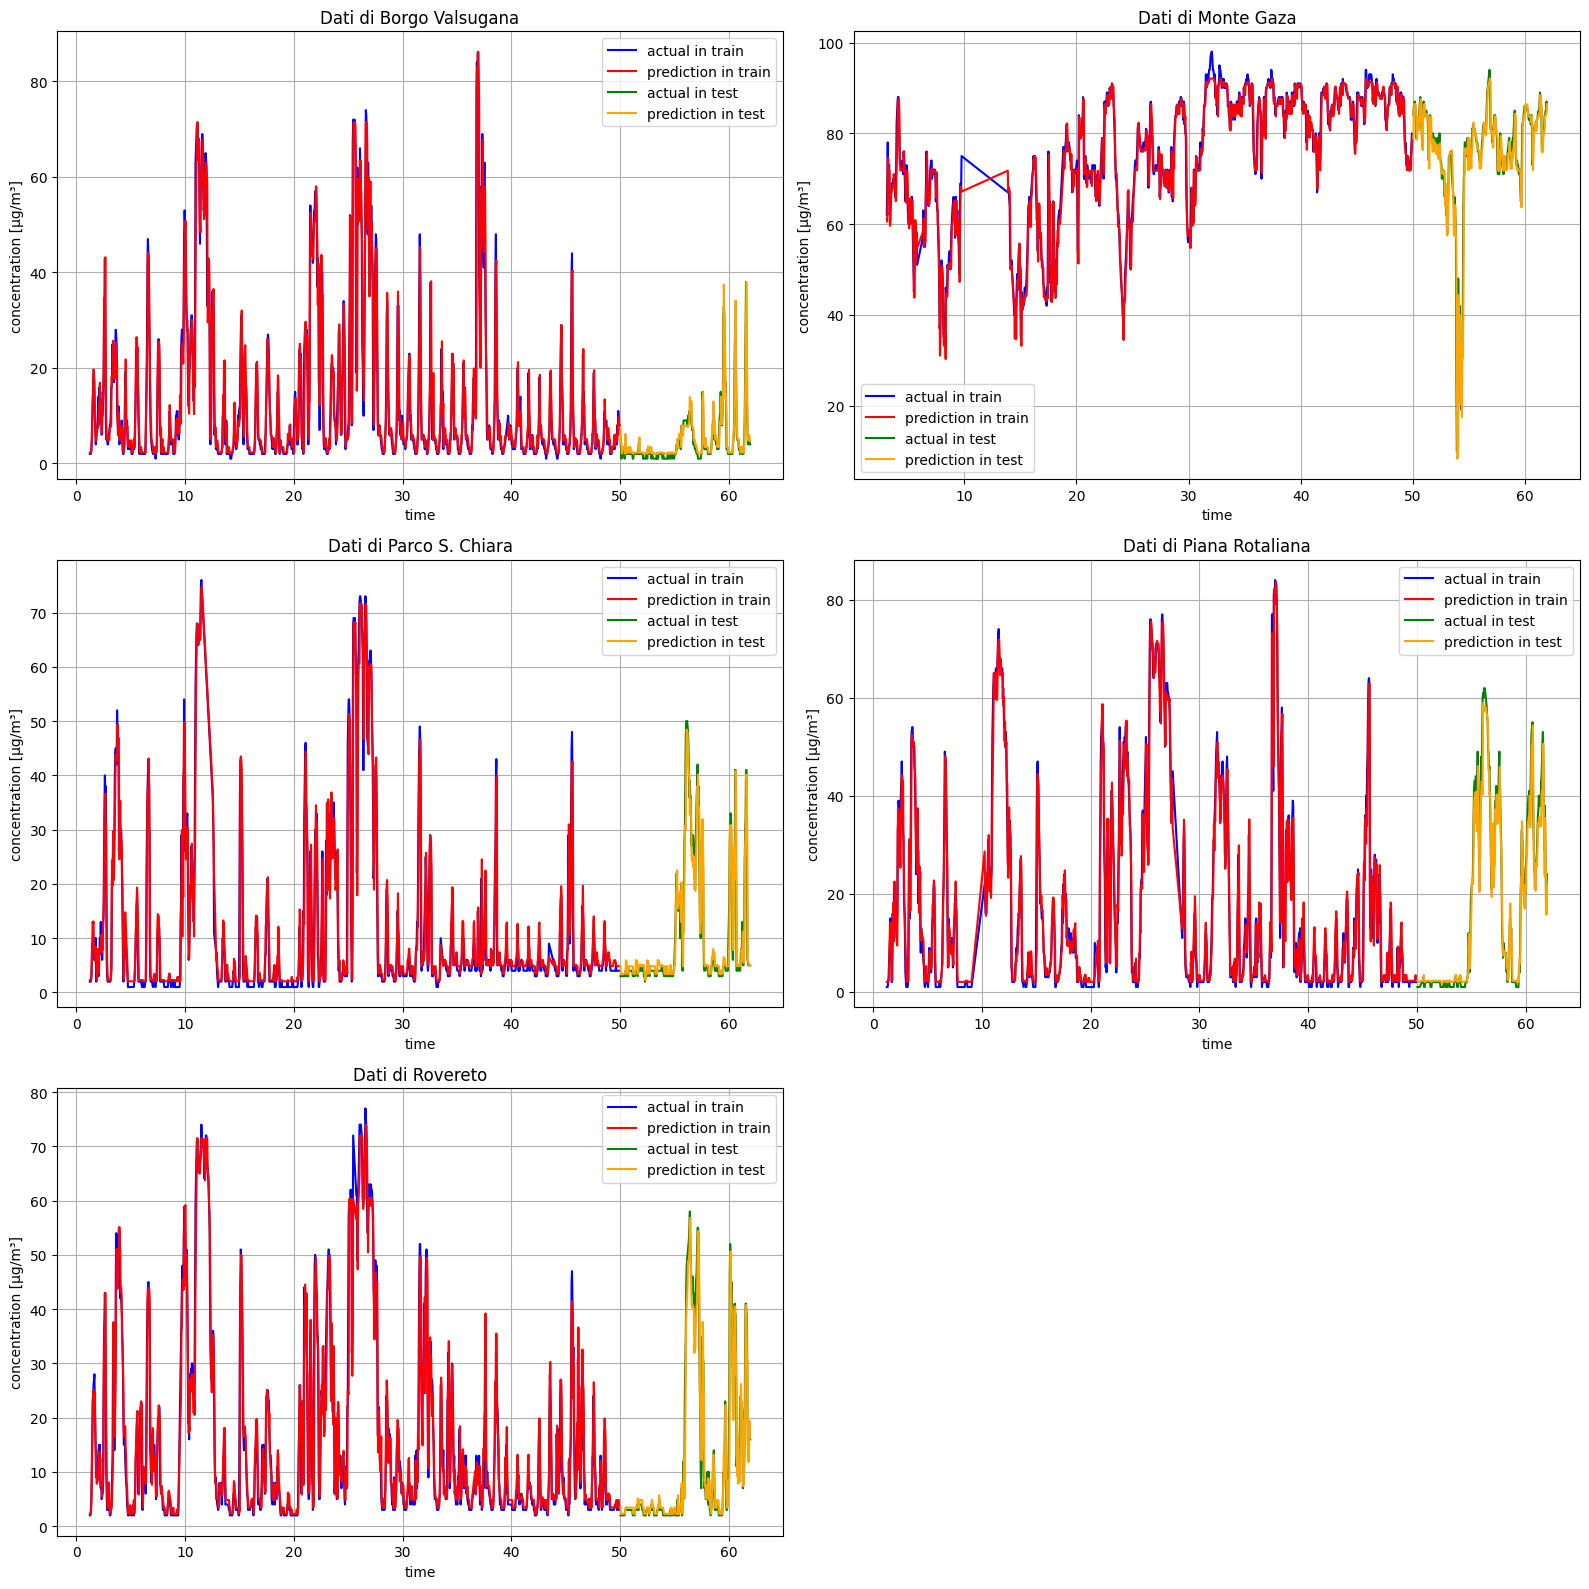

In [29]:
fs.plot_predictions(full_O3_h_tr, full_O3_h_te)

# Modelli giornalieri

## PM10

In [3]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM10_df = pd.read_csv('../../data/processed/dataset_day_PM10_processed.csv')
day_PM10_df.dropna(inplace=True)

### Pipeline

In [5]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in day_PM10_df.columns if col.startswith('station_')]
num_features = day_PM10_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_PM10_d = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_PM10_d = Pipeline([('preprocessor', preprocessor_PM10_d), ('regressor', RandomForestRegressor(random_state=seed))])

# griglia degli iperparametri
#param_grid_rfr = {'regressor__n_estimators': [100, 200, 500],                   # numero di alberi
#                    'regressor__max_depth': [5, 10, 20, None],                  # massima profondità degli alberi
#                    'regressor__min_samples_split': [2, 5, 10],                 # numero minimo di sample per creare una diramazione
#                    'regressor__min_samples_leaf': [1, 2, 5],                   # numero minimo di sample per foglia
#                    'regressor__max_features': [1.0, 'sqrt', 'log2'],           # numero massimo di feature considerate per uno split
#                    'regressor__bootstrap': [True, False]}                      # bootstrap


param_grid_rfr = {'regressor__n_estimators': [200],                              # numero di alberi
                    'regressor__max_depth': [5],                                 # massima profondità degli alberi
                    'regressor__min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'regressor__min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'regressor__max_features': [1.0, 'sqrt'],                    # numero massimo di feature considerate per uno split
                    'regressor__bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_PM10_d = GridSearchCV(estimator=pipeline_PM10_d,                                 # usiamo Random Forest con la pipeline integrata
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [6]:
# splittiamo il dataset
feature_cols = list(num_features) + list(non_num_features)

# creiamo train e test
PM10_d_X_train, PM10_d_X_test, PM10_d_y_train, PM10_d_y_test = fs.get_train_test(day_PM10_df, 0.8, feature_cols)

### Allenamento modello

In [7]:
# training
rfr_PM10_d.fit(PM10_d_X_train, PM10_d_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['NO2_1', 'PM10_1', 'PM10_2', 'PM10_diff_1', 'cos_week_day', 'day',
       'elevation', 'power_area_50_1', 'precipitation', 'sin_week_day',
       'temperature'],
      dtype='object')),
                                                                        ('one-...
                                                                          'station_Rovereto',
                                                                          'station_Via '
                                                                          'Bolzano'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=12))]),
             n_jobs=-1,
             param_grid={'regressor__bootstrap': [True],
                         'regressor__max_depth': [5],
                         'regressor__max_features': [1.0, 'sqrt'],
                         'regressor__min_samples_leaf': [5],
                         'regressor__min_samples_split': [2],
                         'regressor__n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [8]:
print("Best score:")
print(rfr_PM10_d.best_score_)
# miglior modello
best_rfr_PM10_d = rfr_PM10_d.best_estimator_

Best score:
-10.274943807143538


### Studio importanza features

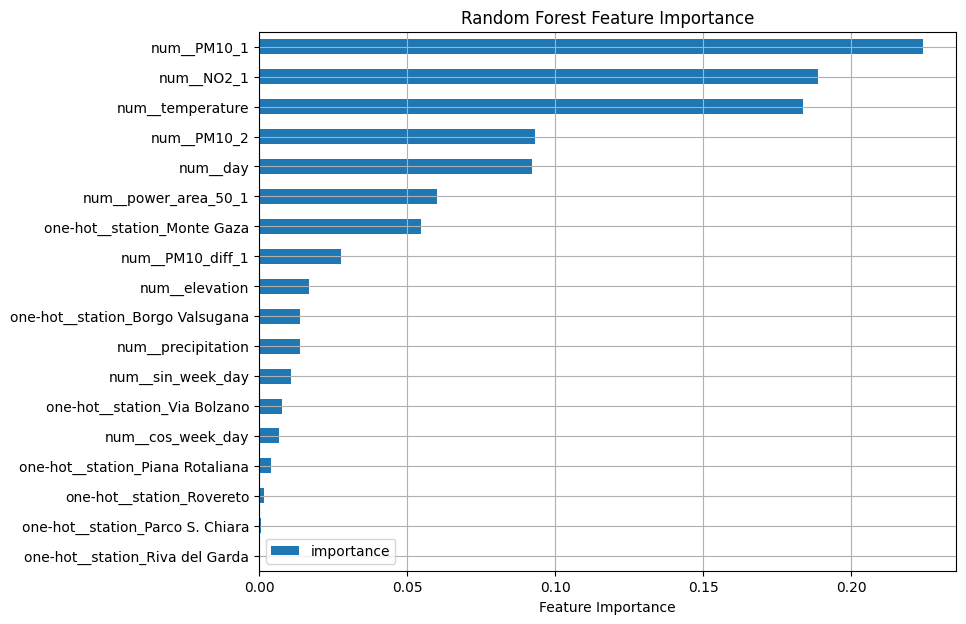

In [9]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfr_PM10_d.named_steps['preprocessor'].get_feature_names_out())

PM10_d_model = best_rfr_PM10_d.named_steps['regressor']

fs.display_importances(PM10_d_model, feature_names)

### Valutazione performance

In [10]:
full_PM10_d_tr = PM10_d_X_train.copy()
full_PM10_d_tr['actual'] = PM10_d_y_train
full_PM10_d_tr['prediction'] = best_rfr_PM10_d.predict(PM10_d_X_train)

full_PM10_d_te = PM10_d_X_test.copy()
full_PM10_d_te['actual'] = PM10_d_y_test
full_PM10_d_te['prediction'] = best_rfr_PM10_d.predict(PM10_d_X_test)

print('Performance su train')
fs.evaluation(full_PM10_d_tr['actual'], full_PM10_d_tr['prediction'])
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(full_PM10_d_te['actual'], full_PM10_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          31.34325361004255
Root Mean Squared Error (RMSE):    5.598504586944852
Mean Absolute Error (MAE):         4.296348373529305
Coefficient of Determination (R2): 0.8631029966046442
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          202.52290956952584
Root Mean Squared Error (RMSE):    14.231054408213252
Mean Absolute Error (MAE):         10.664046392549402
Coefficient of Determination (R2): 0.5670414477318945


(202.52290956952584,
 14.231054408213252,
 10.664046392549402,
 0.5670414477318945)

### Grafici previsioni

In [11]:
# aggiungiamo il tempo
full_PM10_d_tr['time'] = full_PM10_d_tr['day']
full_PM10_d_te['time'] = full_PM10_d_te['day']

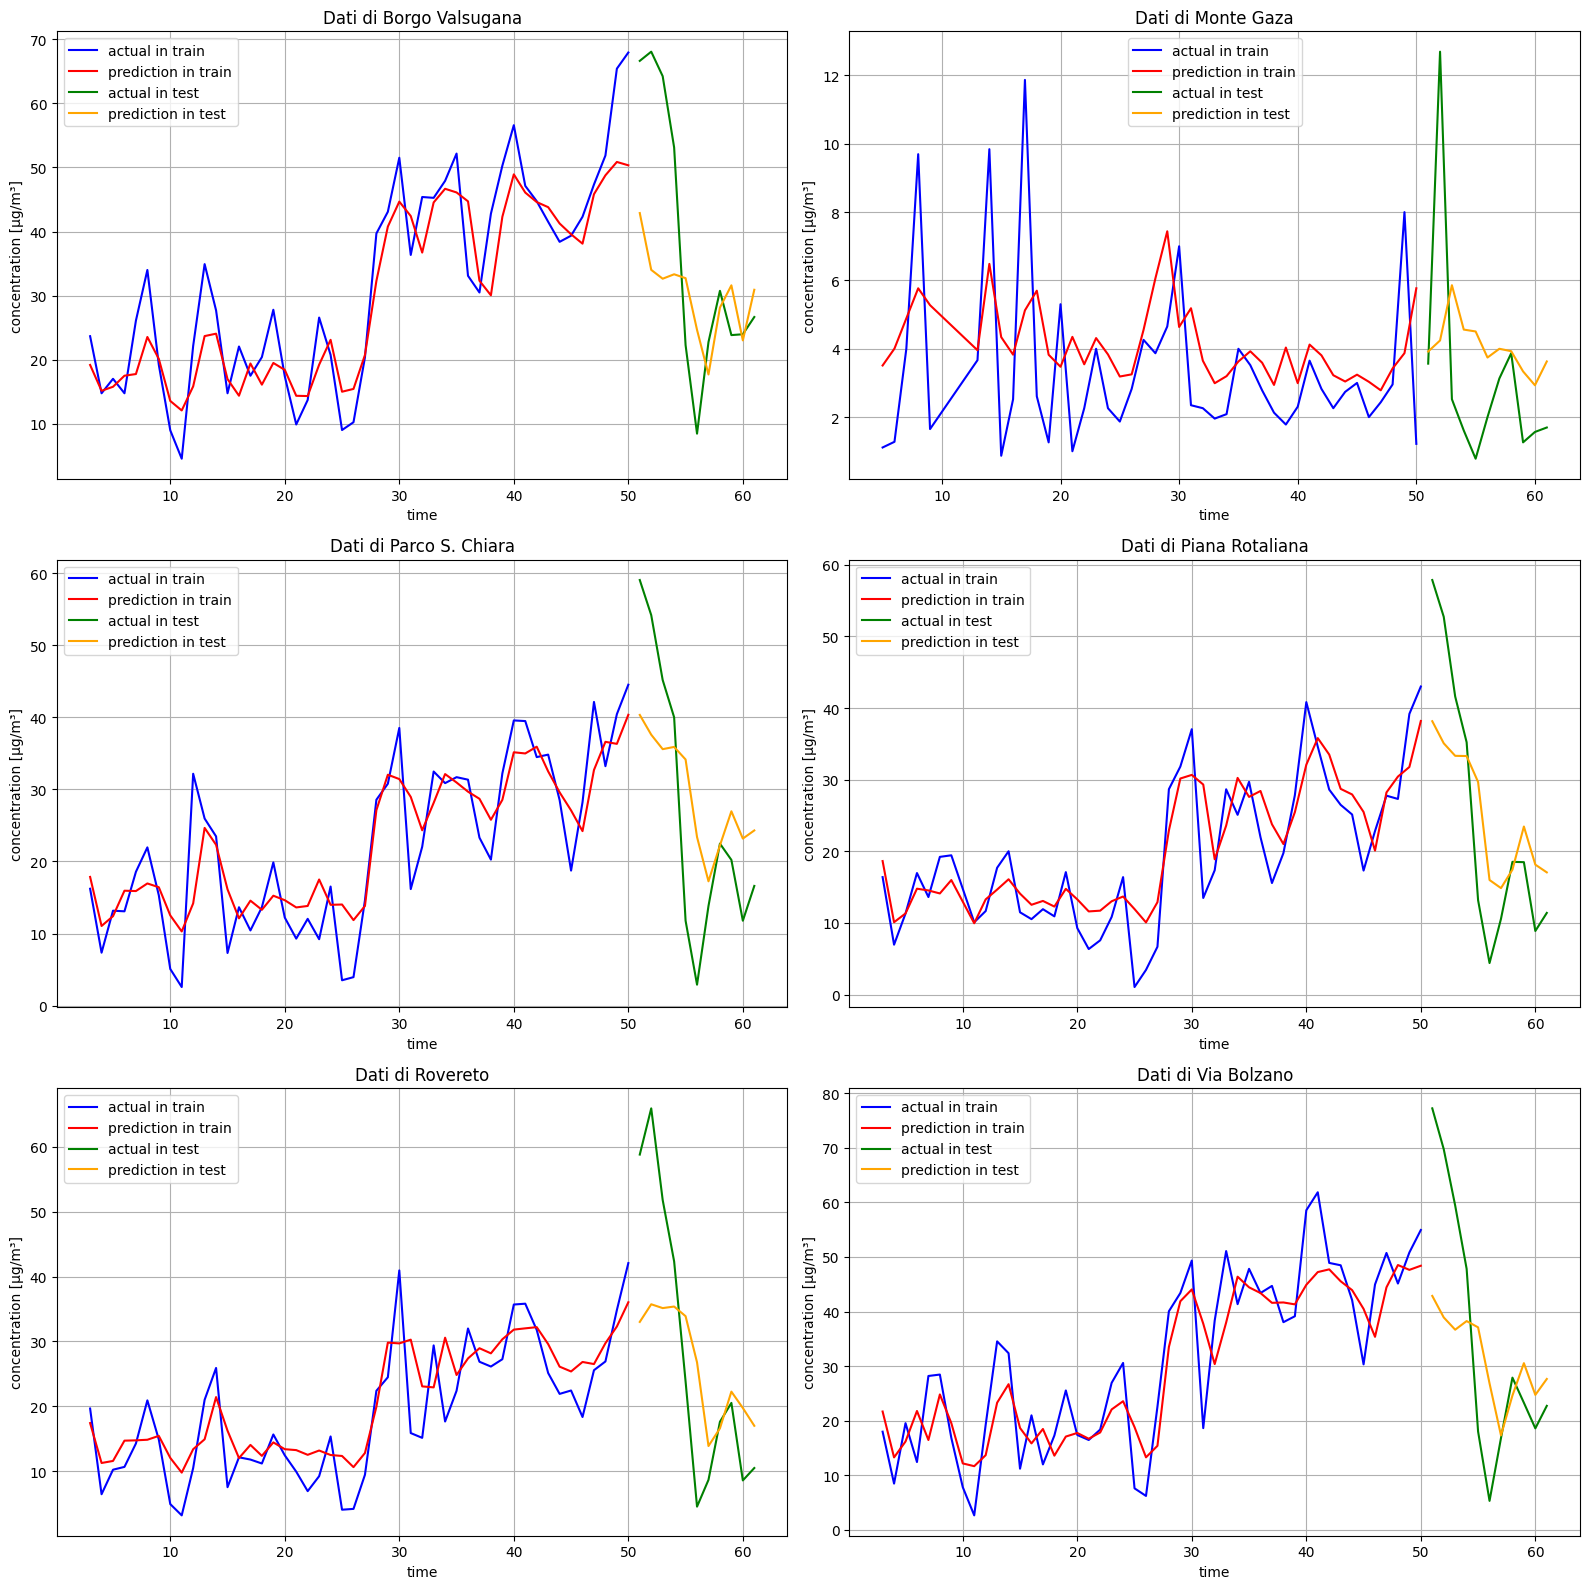

In [12]:
fs.plot_predictions(full_PM10_d_tr, full_PM10_d_te)

## PM2.5

In [13]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM25_df = pd.read_csv('../../data/processed/dataset_day_PM2_5_processed.csv')
day_PM25_df.dropna(inplace=True)

### Pipeline

In [14]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in day_PM25_df.columns if col.startswith('station_')]
num_features = day_PM25_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_PM25_d = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_PM25_d = Pipeline([('preprocessor', preprocessor_PM25_d), ('regressor', RandomForestRegressor(random_state=seed))])

# griglia degli iperparametri
#param_grid_rfr = {'regressor__n_estimators': [100, 200, 500],                   # numero di alberi
#                    'regressor__max_depth': [5, 10, 20, None],                  # massima profondità degli alberi
#                    'regressor__min_samples_split': [2, 5, 10],                 # numero minimo di sample per creare una diramazione
#                    'regressor__min_samples_leaf': [1, 2, 5],                   # numero minimo di sample per foglia
#                    'regressor__max_features': [1.0, 'sqrt', 'log2'],           # numero massimo di feature considerate per uno split
#                    'regressor__bootstrap': [True, False]}                      # bootstrap


param_grid_rfr = {'regressor__n_estimators': [200],                              # numero di alberi
                    'regressor__max_depth': [5],                                 # massima profondità degli alberi
                    'regressor__min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'regressor__min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'regressor__max_features': [1.0, 'sqrt'],                    # numero massimo di feature considerate per uno split
                    'regressor__bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_PM25_d = GridSearchCV(estimator=pipeline_PM25_d,                                 # usiamo Random Forest con la pipeline integrata
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

In [15]:
# splittiamo il dataset
feature_cols = list(num_features) + list(non_num_features)

# creiamo train e test
PM25_d_X_train, PM25_d_X_test, PM25_d_y_train, PM25_d_y_test = fs.get_train_test(day_PM25_df, 0.8, feature_cols)

### Allenamento modello

In [16]:
# training
rfr_PM25_d.fit(PM25_d_X_train, PM25_d_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['NO2_1', 'PM2.5_1', 'PM2.5_2', 'PM2.5_diff_1', 'cos_week_day', 'day',
       'elevation', 'power_area_50_1', 'precipitation', 'sin_week_day',
       'temperature'],
      dtype='object')),
                                                                        ('o...
                                                                          'station_Rovereto',
                                                                          'station_Via '
                                                                          'Bolzano'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=12))]),
             n_jobs=-1,
             param_grid={'regressor__bootstrap': [True],
                         'regressor__max_depth': [5],
                         'regressor__max_features': [1.0, 'sqrt'],
                         'regressor__min_samples_leaf': [5],
                         'regressor__min_samples_split': [2],
                         'regressor__n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [17]:
print("Best score:")
print(rfr_PM25_d.best_score_)
# miglior modello
best_rfr_PM25_d = rfr_PM25_d.best_estimator_

Best score:
-7.806218776809613


### Studio importanza features

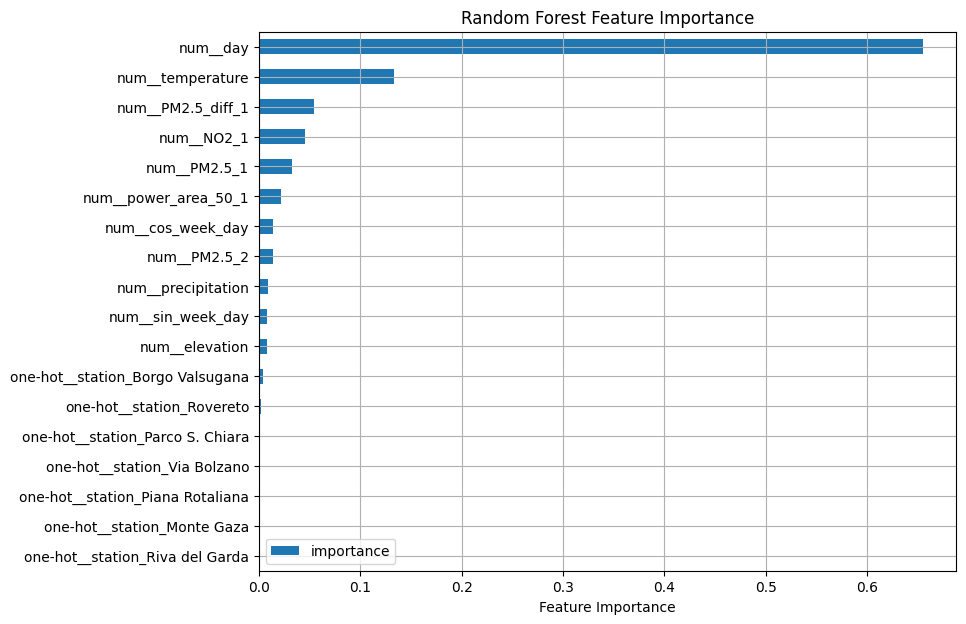

In [19]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfr_PM25_d.named_steps['preprocessor'].get_feature_names_out())

PM25_d_model = best_rfr_PM25_d.named_steps['regressor']

fs.display_importances(PM25_d_model, feature_names)

### Valutazione performance

In [20]:
full_PM25_d_tr = PM25_d_X_train.copy()
full_PM25_d_tr['actual'] = PM25_d_y_train
full_PM25_d_tr['prediction'] = best_rfr_PM25_d.predict(PM25_d_X_train)

full_PM25_d_te = PM25_d_X_test.copy()
full_PM25_d_te['actual'] = PM25_d_y_test
full_PM25_d_te['prediction'] = best_rfr_PM25_d.predict(PM25_d_X_test)

print('Performance su train')
fs.evaluation(full_PM25_d_tr['actual'], full_PM25_d_tr['prediction'])
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(full_PM25_d_te['actual'], full_PM25_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          11.752224430076287
Root Mean Squared Error (RMSE):    3.428151751319694
Mean Absolute Error (MAE):         2.634437978155755
Coefficient of Determination (R2): 0.8709819741859738
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          224.57816207547583
Root Mean Squared Error (RMSE):    14.985932139025447
Mean Absolute Error (MAE):         12.761319970010039
Coefficient of Determination (R2): 0.14347916854085552


(224.57816207547583,
 14.985932139025447,
 12.761319970010039,
 0.14347916854085552)

### Grafici previsioni

In [21]:
# aggiungiamo il tempo
full_PM25_d_tr['time'] = full_PM25_d_tr['day']
full_PM25_d_te['time'] = full_PM25_d_te['day']

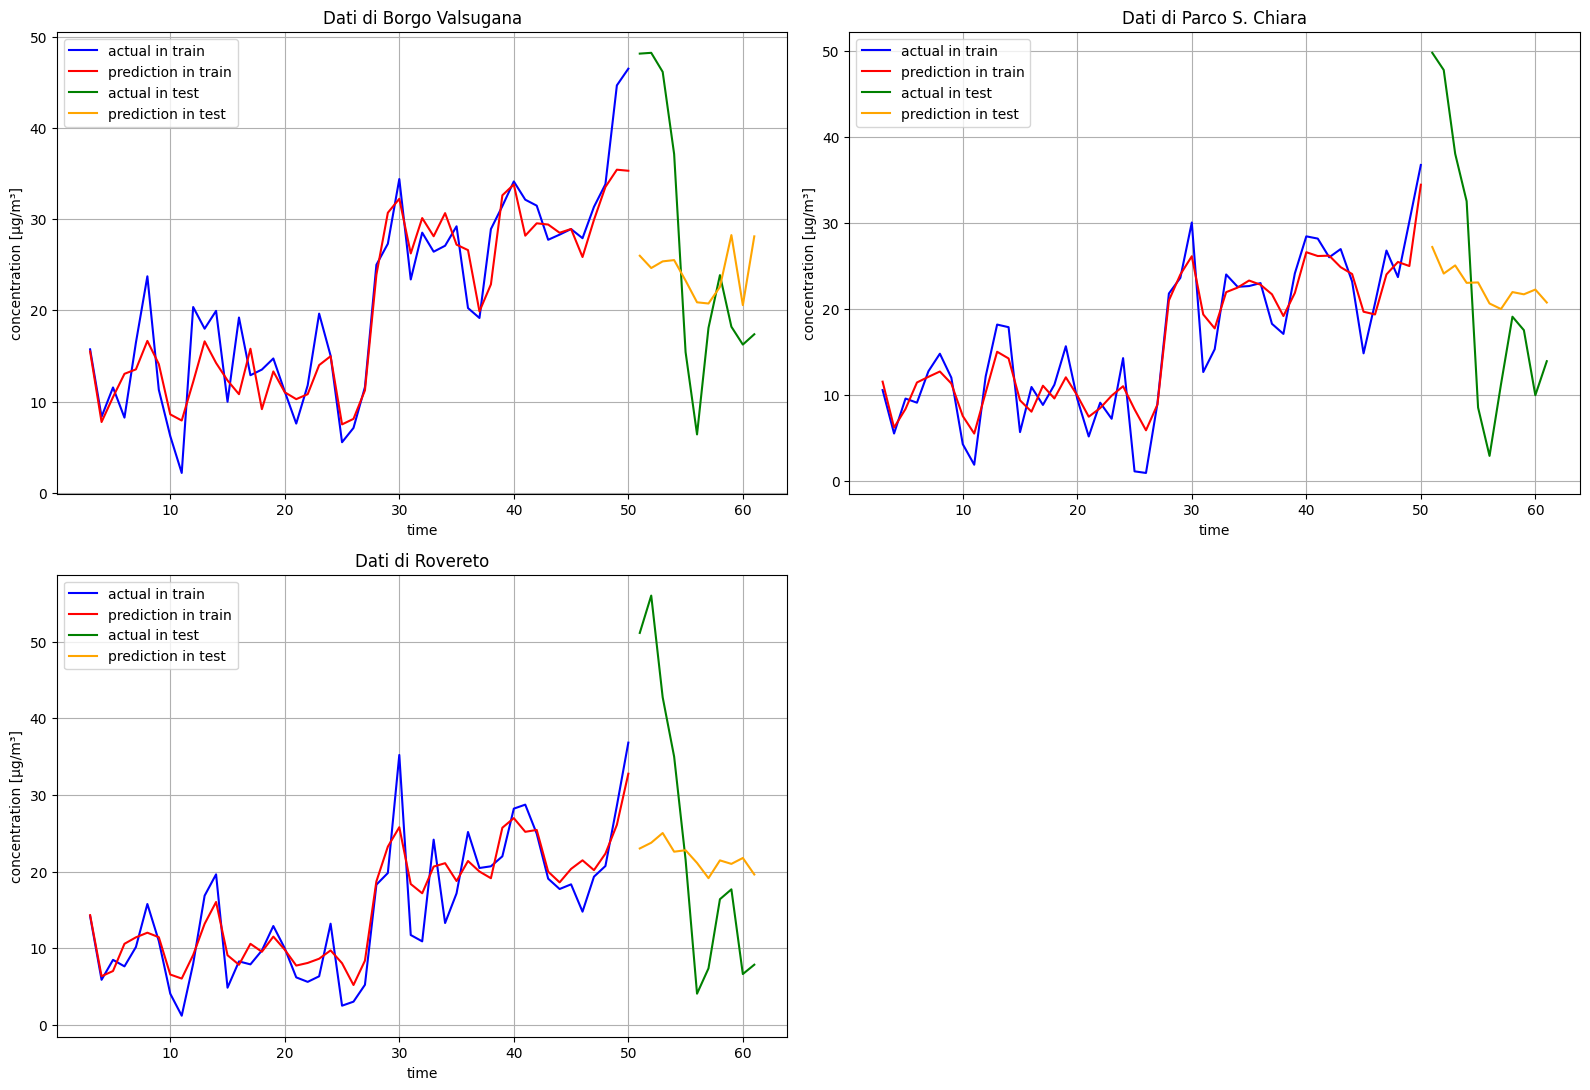

In [22]:
fs.plot_predictions(full_PM25_d_tr, full_PM25_d_te)

## Ozono

In [23]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_O3_df = pd.read_csv('../../data/processed/dataset_day_O3_processed.csv')
day_O3_df.dropna(inplace=True)

### Pipeline

In [25]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in day_O3_df.columns if col.startswith('station_')]
num_features = day_O3_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_O3_d = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_O3_d = Pipeline([('preprocessor', preprocessor_O3_d), ('regressor', RandomForestRegressor(random_state=seed))])

# griglia degli iperparametri
#param_grid_rfr = {'regressor__n_estimators': [100, 200, 500],                   # numero di alberi
#                    'regressor__max_depth': [5, 10, 20, None],                  # massima profondità degli alberi
#                    'regressor__min_samples_split': [2, 5, 10],                 # numero minimo di sample per creare una diramazione
#                    'regressor__min_samples_leaf': [1, 2, 5],                   # numero minimo di sample per foglia
#                    'regressor__max_features': [1.0, 'sqrt', 'log2'],           # numero massimo di feature considerate per uno split
#                    'regressor__bootstrap': [True, False]}                      # bootstrap


param_grid_rfr = {'regressor__n_estimators': [200],                              # numero di alberi
                    'regressor__max_depth': [5],                                 # massima profondità degli alberi
                    'regressor__min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'regressor__min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'regressor__max_features': [1.0, 'sqrt'],                    # numero massimo di feature considerate per uno split
                    'regressor__bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_O3_d = GridSearchCV(estimator=pipeline_O3_d,                                 # usiamo Random Forest con la pipeline integrata
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

In [26]:
# splittiamo il dataset
feature_cols = list(num_features) + list(non_num_features)

# creiamo train e test
O3_d_X_train, O3_d_X_test, O3_d_y_train, O3_d_y_test = fs.get_train_test(day_O3_df, 0.8, feature_cols)

### Allenamento modello

In [27]:
# training
rfr_O3_d.fit(O3_d_X_train, O3_d_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['NO2_1', 'O3_1', 'O3_2', 'O3_diff_1', 'PM10_1', 'cos_week_day', 'day',
       'elevation', 'power_area_50_1', 'precipitation', 'sin_week_day',
       'temperature'],
      dtype='object')),
                                                                        ('o...
                                                                          'station_Rovereto',
                                                                          'station_Via '
                                                                          'Bolzano'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=12))]),
             n_jobs=-1,
             param_grid={'regressor__bootstrap': [True],
                         'regressor__max_depth': [5],
                         'regressor__max_features': [1.0, 'sqrt'],
                         'regressor__min_samples_leaf': [5],
                         'regressor__min_samples_split': [2],
                         'regressor__n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [28]:
print("Best score:")
print(rfr_O3_d.best_score_)
# miglior modello
best_rfr_O3_d = rfr_O3_d.best_estimator_

Best score:
-20.47580809455023


### Studio importanza features

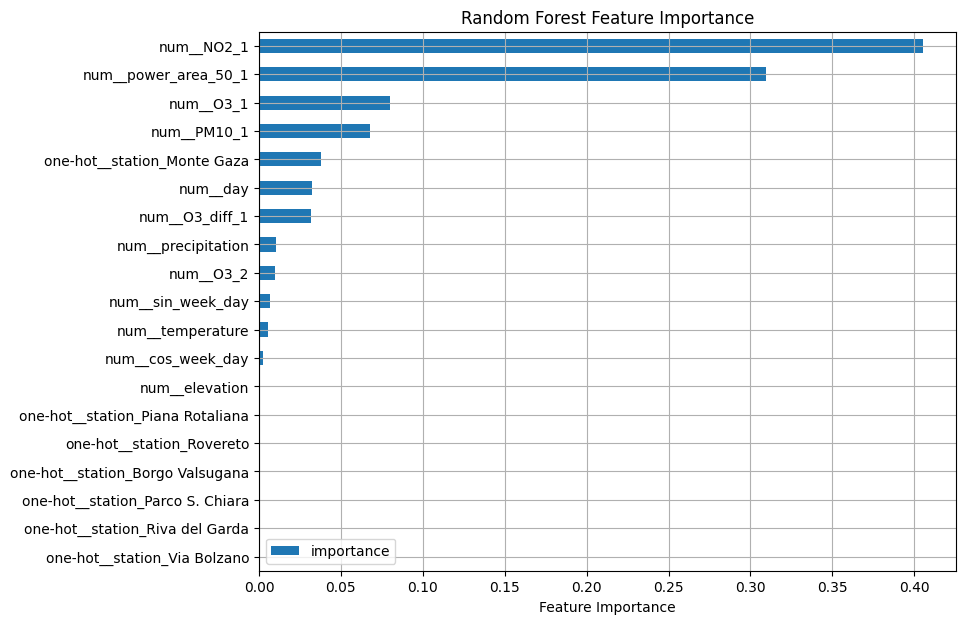

In [29]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfr_O3_d.named_steps['preprocessor'].get_feature_names_out())

O3_d_model = best_rfr_O3_d.named_steps['regressor']

fs.display_importances(O3_d_model, feature_names)

### Valutazione performance

In [30]:
full_O3_d_tr = O3_d_X_train.copy()
full_O3_d_tr['actual'] = O3_d_y_train
full_O3_d_tr['prediction'] = best_rfr_O3_d.predict(O3_d_X_train)

full_O3_d_te = O3_d_X_test.copy()
full_O3_d_te['actual'] = O3_d_y_test
full_O3_d_te['prediction'] = best_rfr_O3_d.predict(O3_d_X_test)

print('Performance su train')
fs.evaluation(full_O3_d_tr['actual'], full_O3_d_tr['prediction'])
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(full_O3_d_te['actual'], full_O3_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          69.1276375613265
Root Mean Squared Error (RMSE):    8.314303191568522
Mean Absolute Error (MAE):         5.791057421007883
Coefficient of Determination (R2): 0.9089793155542003
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          145.19349625069083
Root Mean Squared Error (RMSE):    12.049626394651861
Mean Absolute Error (MAE):         9.934256598191068
Coefficient of Determination (R2): 0.8152391094980503


(145.19349625069083, 12.049626394651861, 9.934256598191068, 0.8152391094980503)

### Grafici previsioni

In [31]:
# aggiungiamo il tempo
full_O3_d_tr['time'] = full_O3_d_tr['day']
full_O3_d_te['time'] = full_O3_d_te['day']

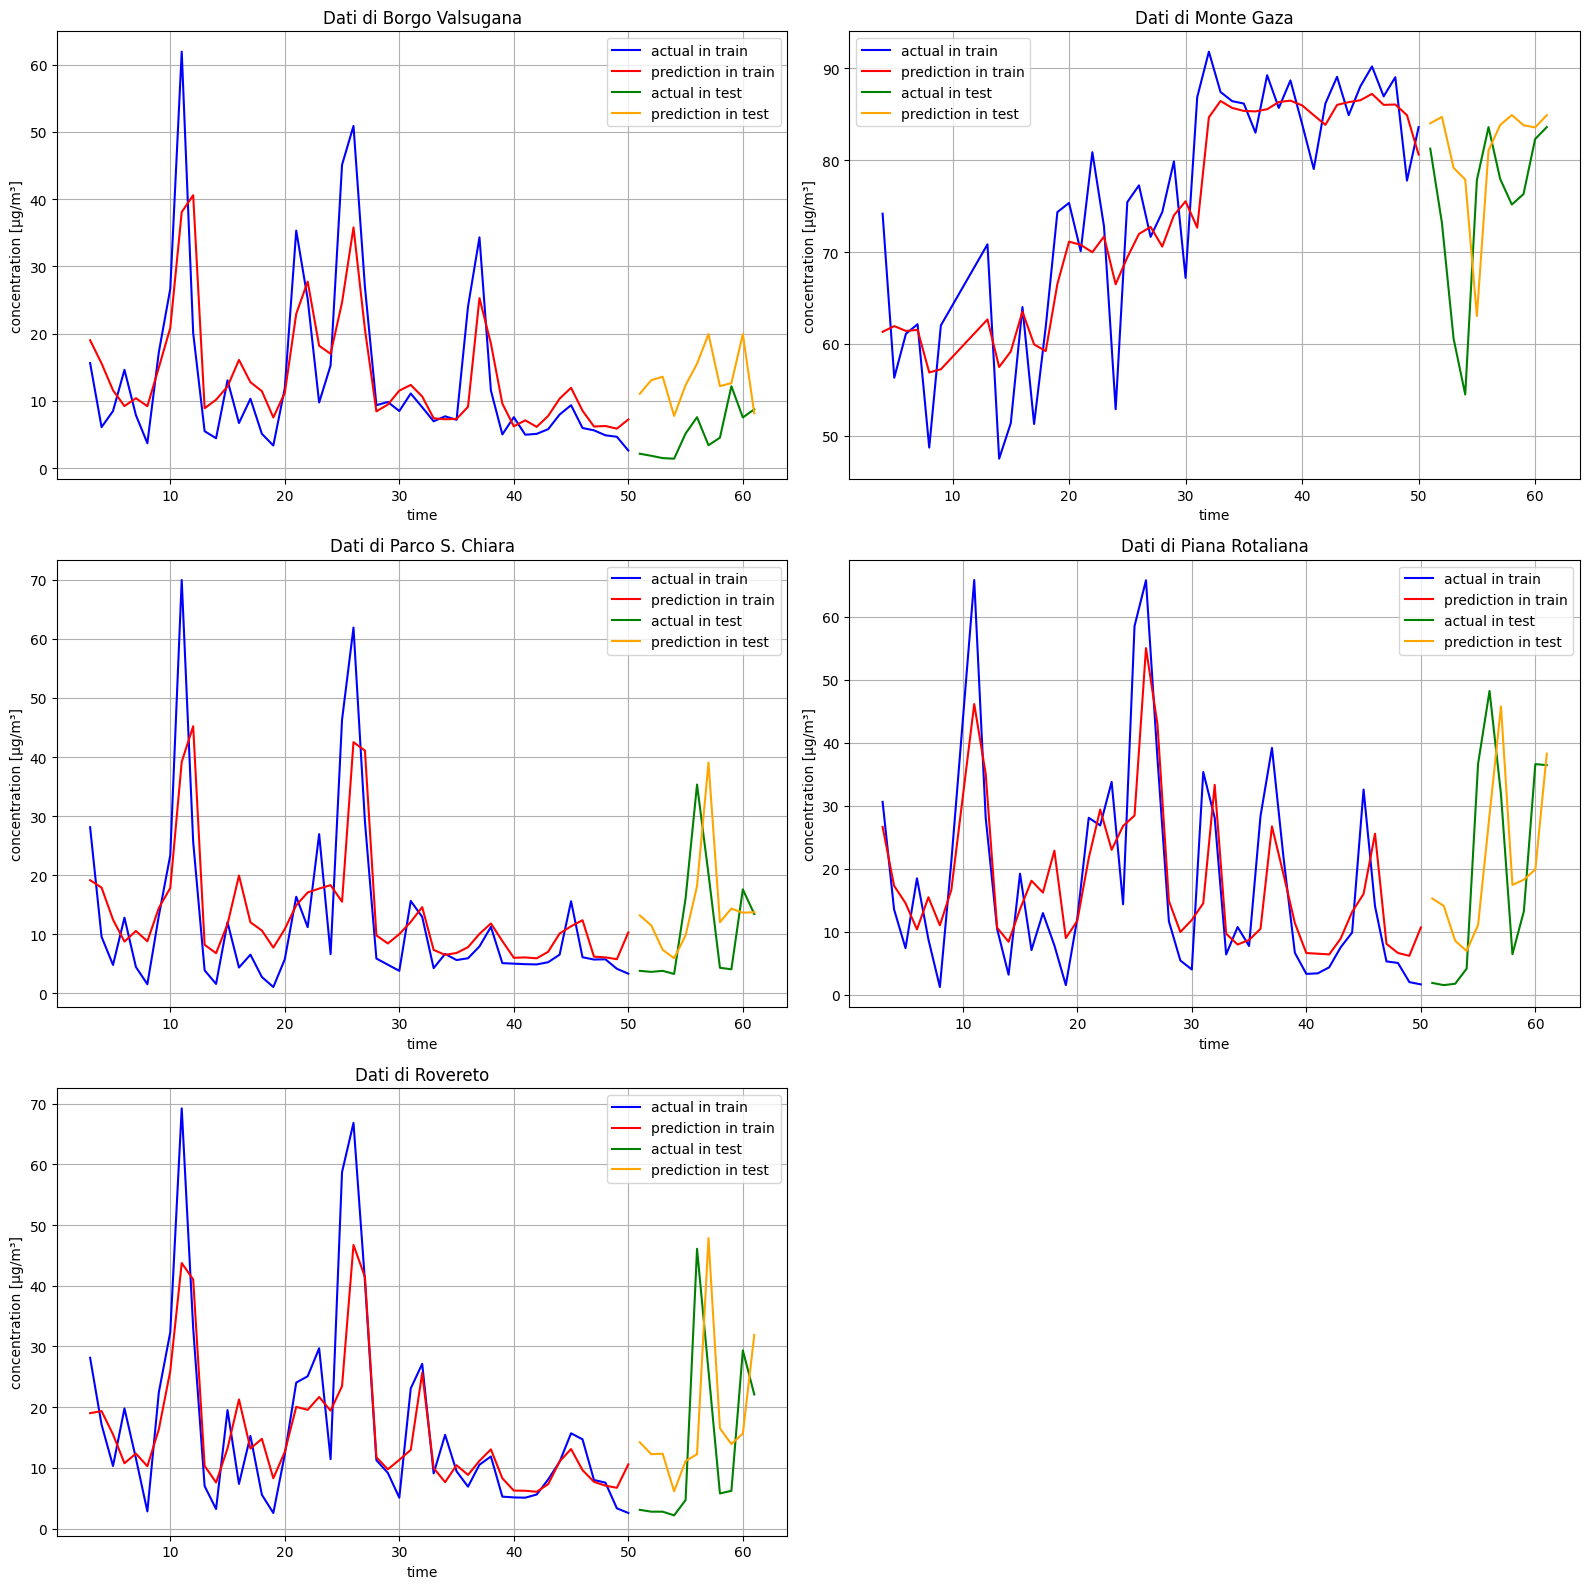

In [32]:
fs.plot_predictions(full_O3_d_tr, full_O3_d_te)